In [1]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import auc
import japanize_matplotlib

In [2]:
data = pd.read_csv("7-4-18_data_new.csv", encoding="shift-jis")
# data = pd.read_csv("7-4-18_data_all.csv")

data["Q4_1"] = 6 - data["Q4_1"]
# data = data.drop(["Q16_1", "Q16_2",], axis = 1)
data = data.fillna(0)
data_filt = data.filter(regex="Q16", axis = 1)
data_filt = 5 - data_filt
# data = data.drop(["Q16_1", "Q16_2", "Q16_3", "Q16_4"], axis = 1)
# data = data.drop(["Q16_3", "Q16_4"], axis = 1)
data = pd.concat([data, data_filt], axis = 1)
# data["SQ2"] = data["SQ2"].round(-1)

# 列名の変更
data = data.rename(columns={
    "Q1": "満足度",
    "Q2_7": "正確性",
    "Q2_8": "更新頻度",
    "Q2_9": "豊富さ",
    "Q2_10": "詳細さ",
    "Q4_1": "他者推薦",
})

outcome_col = "他者推薦" 
state_col = "正確性"
score_rec = np.array([0, 1, 2, 3, 4],dtype= "float") 

th_sh = data[state_col].quantile(0.75)
# th_sh = data["豊富さ"].mean()
data["treatment"] = (data[state_col] >= th_sh).astype(int)
seg_col = "Q7_4"
#交絡因子
# cfd = ["更新頻度", "詳細さ", "正確性", "Q5_2"]
ftr_cols = [c for c in data.columns]
ftr_cols.remove("他者推薦")
ftr_cols = [i for i in ftr_cols if i not in ['正確性', '更新頻度', '詳細さ',"豊富さ"]]
ftr_cols.remove("treatment")
ftr_cols.remove(seg_col)
ftr_cols.remove("SQ2")

ftr_cols =["SQ1","SQ3","SQ8","Q5_2","Q12_2","Q14_2","Q28","Q29","Q30","Q31","Q38","Q39","Q41"]

X = pd.get_dummies(data[ftr_cols], drop_first=False).values
A = data["treatment"].astype(int).values

levels = pd.Series(data[outcome_col]).dropna().unique().tolist()
levels_sorted = sorted(levels)  
y_to_index = {lev:i for i, lev in enumerate(levels_sorted)}
Y = pd.Series(data[outcome_col]).map(y_to_index).astype(int).values

K = len(levels_sorted)

In [3]:
def ensure_numpy(x):
    if isinstance(x, (pd.Series, pd.DataFrame)):
        return x.values
    return np.asarray(x) #numpy配列に変換

def clip_eps(arr, eps=1e-4):
    return np.clip(arr, eps, 1 - eps) #指定範囲でクリッピング

In [4]:
def proba_aligned(estimator, X_va, K):
    """
    確率予測(predict_proba) が (n,k_obs) でも K 列に整列。
    欠落クラスは0で埋め、行正規化（全ゼロ行は一様）。
    """
    p_raw = estimator.predict_proba(X_va) #順序回帰モデルによる予測確率を出力し、各クラスの確率値の行列を取得
    if hasattr(estimator, "classes_"):
        cls = np.asarray(estimator.classes_, dtype=int)
    elif hasattr(estimator, "calibrated_classifiers_"):
        cls = np.asarray(estimator.calibrated_classifiers_[0].classes_, dtype=int)
    else:
        raise RuntimeError("Estimator has no classes_.")
    out = np.zeros((X_va.shape[0], K), dtype=float) #サンプル数×クラス数の行列
    out[:, cls] = p_raw #クラスの配置
    s = out.sum(axis=1, keepdims=True)              
    np.divide(out, s, out=out, where=(s > 0)) #行ごとの確率を正規化      
    zero_rows = (s[:, 0] == 0)                      
    if np.any(zero_rows):
        out[zero_rows, :] = 1.0 / K #ゼロ確率のサンプルに対する一様分布
    return out

In [5]:
def make_calibrated_or_base(base_estimator, method, y, default_cv=3):
    """
    モデルに対してキャリブレーションを行い、
    クラスの頻度に合わせたクロスバリデーションで調整する
    """
    if method not in ("isotonic", "sigmoid"):
        return base_estimator #これらを除き、キャリブレーションを行わない
    if y is None or len(y) == 0:
        return base_estimator #データ無しも同様
    _, counts = np.unique(y, return_counts=True) #目的変数の値の計算
    min_count = counts.min() if len(counts) else 0
    if min_count >= 2: #サンプル数に応じた交差検証
        return CalibratedClassifierCV(base_estimator, method=method, cv=default_cv)
    else:
        return base_estimator

In [6]:
def make_seg_from_cuts(S, cut1, cut2):
    """seg0: S<=cut1, seg1: cut1<S<=cut2, seg2: S>cut2"""
    S = np.asarray(S)
    return (S > cut1).astype(int) + (S > cut2).astype(int)

def fit_ps_oof(X, A, n_splits=5, random_state=42, C=0.5,
    class_weight= None,
    calibration="isotonic",
    max_iter=3000,eps=1e-4):
    """
    PSをアウトカム無しで推定（out-of-fold）。
    セグメント内でサンプルが少ない場合は自動で分割数を落とす。
    """
    A = np.asarray(A).astype(int).ravel()
    X = np.asarray(X, dtype=float)
    n = len(A)

    n1 = int(A.sum())
    n0 = int(n - n1)
    k = min(n_splits, n1, n0)
    if k < 2:
        p = float(A.mean())
        return np.clip(np.full(n, p, dtype=float), eps, 1-eps)

    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    e_raw = np.empty(n, dtype=float)

    base_ps = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(
            max_iter=max_iter,
            solver="lbfgs",
            C=float(C),
            class_weight=class_weight
        ))
    ])
    
    ps_hgb = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=400, random_state=123)
    ps_rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=10, class_weight=None, random_state=123, n_jobs=-1)

    for tr, te in cv.split(X, A):
        ps_model = make_calibrated_or_base(base_ps, calibration, A[tr], default_cv=3)
        ps_model.fit(X[tr], A[tr])
        e_raw[te] = ps_model.predict_proba(X[te])[:, 1]

    # clip（極端値で重みが爆発するのを防ぐ）
    e_hat = np.clip(e_raw, 1e-2, 1 - 1e-2)
    return e_hat

def ess(w):
    # w = np.asarray(w, dtype=float)
    return (w.sum() ** 2) / (np.square(w).sum() + 1e-12)

def weighted_smd(X, A, e_hat):
    X = np.asarray(X, dtype=float)
    A = np.asarray(A).astype(int).ravel()
    e = np.asarray(e_hat, dtype=float)

    Xt = X[A == 1]
    Xc = X[A == 0]
    wt = 1.0 / e[A == 1]
    wc = 1.0 / (1.0 - e[A == 0])

    mt = np.average(Xt, axis=0, weights=wt)
    mc = np.average(Xc, axis=0, weights=wc)

    vt = np.average((Xt - mt) ** 2, axis=0, weights=wt)
    vc = np.average((Xc - mc) ** 2, axis=0, weights=wc)

    smd = (mt - mc) / np.sqrt((vt + vc) / 2.0 + 1e-12)
    abs_smd = np.abs(smd)

    return float(np.nanmax(abs_smd)), float(np.nanmean(abs_smd))

def rank_cuts_design_optimal(S, A, X, min_total_per_seg, min_each_treat_per_seg,
                             n_splits_ps=5, random_state=42, cap_weight=None,ps_kwargs=None,):
    """
    アウトカムを使わず、design（overlap/balance/ESS）でcutをランキング
    """
    S = np.asarray(S)
    A = np.asarray(A).astype(int).ravel()
    X = np.asarray(X, dtype=float)

    # 欠損（NaN）はここでは除外してcut探索（必要なら後で別扱い）
    ok = ~pd.isna(S)
    S0, A0, X0 = S[ok], A[ok], X[ok]

    uniq = np.sort(np.unique(S0))
    cuts = uniq[:-1]  # 最大値は境界にしない
    
    ps_kwargs = {} if ps_kwargs is None else dict(ps_kwargs)

    rows = []
    for i, c1 in enumerate(cuts):
        for c2 in cuts[i+1:]:
            seg = make_seg_from_cuts(S0, c1, c2)

            # セグメントの成立条件（両群がいて十分な数）
            seg_ok = True
            seg_info = []
            worst_max_smd = 0.0
            worst_extreme = 0.0
            worst_max_w = 0.0
            min_ess_ratio = 1.0

            for g in [0, 1, 2]:
                idx = (seg == g)
                n = int(idx.sum())
                n1 = int(((A0 == 1) & idx).sum())
                n0c = int(((A0 == 0) & idx).sum())

                if (n < min_total_per_seg) or (n1 < min_each_treat_per_seg) or (n0c < min_each_treat_per_seg):
                    seg_ok = False
                    break

                e_hat = fit_ps_oof(X0[idx], A0[idx], n_splits=n_splits_ps, random_state=random_state, **ps_kwargs)
                if e_hat is None:
                    seg_ok = False
                    break

                # overlap/weights
                extreme = float(((e_hat < 0.05) | (e_hat > 0.95)).mean())
                w = np.where(A0[idx] == 1, 1.0 / e_hat, 1.0 / (1.0 - e_hat))
                if cap_weight is not None:
                    w = np.minimum(w, cap_weight)
                ess_ratio = float(ess(w) / len(w))
                max_w = float(w.max())

                # balance
                max_smd, mean_smd = weighted_smd(X0[idx], A0[idx], e_hat)

                worst_max_smd = max(worst_max_smd, max_smd)
                worst_extreme = max(worst_extreme, extreme)
                worst_max_w = max(worst_max_w, max_w)
                min_ess_ratio = min(min_ess_ratio, ess_ratio)

                seg_info.append((g, n, n1, n0c, max_smd, extreme, ess_ratio, max_w))

            if not seg_ok:
                continue

            rows.append({
                "cut1": c1,
                "cut2": c2,
                "worst_max_abs_SMD": worst_max_smd,
                "worst_extreme_ps_rate": worst_extreme,
                "min_ess_ratio": min_ess_ratio,
                "worst_max_weight": worst_max_w,
                "seg_info": seg_info
            })

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    # “minimax設計最適”の並び
    out = out.sort_values(
        ["worst_max_abs_SMD", "worst_extreme_ps_rate", "min_ess_ratio", "worst_max_weight","cut1"],
        ascending=[True, True, False, True, True]
    ).reset_index(drop=True)
    return out

In [7]:
S = data[seg_col].replace(0, np.nan).to_numpy()  # 0埋めしている場合は欠損扱いへ

ps_kwargs_design = dict(
    C=0.5,               # 小さめほど正則化が強い（極端PSを抑えやすい）
    calibration= "isotonic",
)
cap_weight_design = 100

rank_design = rank_cuts_design_optimal(
    S=S, A=A, X=X,
    min_total_per_seg=200, min_each_treat_per_seg=10,
    cap_weight=cap_weight_design,
    ps_kwargs=ps_kwargs_design
)

print(rank_design.head(10))

best = rank_design.iloc[0]
cut1, cut2 = best["cut1"], best["cut2"]
data["seg_opt"] = make_seg_from_cuts(S, cut1, cut2)
print("best cuts:", cut1, cut2)
print("seg info:", best["seg_info"])
print(pd.crosstab(data["seg_opt"], data["treatment"]))

base_cols=["SQ1","SQ3","SQ8","Q5_2","Q12_2","Q14_2","Q28","Q29","Q30","Q31","Q38","Q39","Q41"]
# base_cols=["SQ3","SQ8","Q5_2","Q12_2","Q17","Q18","Q28","Q29","Q38","Q39","Q41"]
X_ps = data[base_cols].copy()

# X_ps["Q5_2"] = X_ps["Q5_2"].astype("Int64").astype("category")
X_ps = pd.get_dummies(X_ps, columns=base_cols, drop_first=True)
# print(X_ps)

   cut1  cut2  worst_max_abs_SMD  worst_extreme_ps_rate  min_ess_ratio  \
0     6     7           0.386565               0.218115       0.139827   
1     5     7           0.497600               0.472868       0.094700   
2     5     6           0.497600               0.472868       0.094700   

   worst_max_weight                                           seg_info  
0             100.0  [(0, 541, 39, 502, 0.3411048598014823, 0.21811...  
1              84.0  [(0, 258, 14, 244, 0.4975998344389446, 0.47286...  
2             100.0  [(0, 258, 14, 244, 0.4975998344389446, 0.47286...  
best cuts: 6 7
seg info: [(0, 541, 39, 502, 0.3411048598014823, 0.21811460258780038, 0.13982724295071372, 61.28786673140059), (1, 341, 84, 257, 0.386564846714482, 0.011730205278592375, 0.1599141433226624, 100.0), (2, 443, 285, 158, 0.08901413300337095, 0.002257336343115124, 0.7114646764629325, 20.656173377165977)]
treatment    0    1
seg_opt            
0          502   39
1          257   84
2          158 

In [8]:
def weighted_smd_detail(X, A, e_hat, cap_weight=100, feature_names=None):
    
    if hasattr(X, "to_numpy"):
        if feature_names is None:
            feature_names = list(X.columns)
        Xv = X.to_numpy()
    else:
        Xv = np.asarray(X)
        if feature_names is None:
            feature_names = [f"x{i}" for i in range(Xv.shape[1])]

    A = np.asarray(A).astype(int).ravel()
    e = np.clip(np.asarray(e_hat).ravel(), 1e-4, 1-1e-4)

    if cap_weight is None:
        wt = A / e
        wc = (1 - A) / (1 - e)
    else:
        wt = A * np.minimum(1.0 / e, cap_weight)
        wc = (1 - A) * np.minimum(1.0 / (1 - e), cap_weight)

    def wmean(x, w):
        m = np.isfinite(x) & np.isfinite(w)
        return float(np.sum(x[m] * w[m]) / np.sum(w[m])) if m.sum() else np.nan

    def wvar(x, w):
        m = np.isfinite(x) & np.isfinite(w)
        if m.sum() == 0:
            return np.nan
        mu = np.sum(x[m] * w[m]) / np.sum(w[m])
        return float(np.sum(w[m] * (x[m] - mu) ** 2) / np.sum(w[m]))

    rows = []
    p = Xv.shape[1]
    xt = Xv[A == 1, :]
    xc = Xv[A == 0, :]
    wt1 = wt[A == 1]
    wc0 = wc[A == 0]

    for j in range(p):
        mt = wmean(xt[:, j], wt1)
        mc = wmean(xc[:, j], wc0)
        vt = wvar(xt[:, j], wt1)
        vc = wvar(xc[:, j], wc0)
        denom = np.sqrt(0.5 * (vt + vc) + 1e-12)
        smd = (mt - mc) / denom if np.isfinite(mt) and np.isfinite(mc) and denom > 0 else np.nan

        rows.append({
            "feature": str(feature_names[j]),
            "smd": smd,
            "abs_smd": abs(smd) if np.isfinite(smd) else np.nan,
            "mean_treated_w": mt,
            "mean_control_w": mc,
            "var_treated_w": vt,
            "var_control_w": vc,
        })

    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False, na_position="last")

def ess_class(w: np.ndarray):
    w = np.asarray(w, dtype=float)
    s1 = np.sum(w)
    s2 = np.sum(w * w)
    return float((s1 * s1) / s2) if s2 > 0 else np.nan

# --- rank_cuts_design_optimal と同じ “欠損除外” で確認 ---
ok = ~pd.isna(S)
S0 = S[ok]
A0 = A[ok]
Y0 = Y[ok].astype(int)

# X は numpy なので列名が消えている。dummiesの列名を復元する
X_df0 = pd.get_dummies(data.loc[ok, ftr_cols], drop_first=False)
X_ps0 = pd.get_dummies(data.loc[ok, base_cols], drop_first=False)
feature_names = list(X_ps0.columns)
X0 = X_df0.values
X1 = X_ps0.values

seg0 = make_seg_from_cuts(S0, cut1, cut2)
per_seg_summary = []
all_rows = []
seg_max_abs = []

for g in [0, 1, 2]:
    idx_g = (seg0 == g)
    n_g = int(idx_g.sum())
    n1 = int(((A0 == 1) & idx_g).sum())
    n0 = int(((A0 == 0) & idx_g).sum())
    print(f"\n--- seg={g} | n={n_g} | treated={n1} | control={n0} ---")

    if n_g == 0 or min(n1, n0) < 2:
        print("skip (too small)")
        continue

    # e_hat = fit_ps_oof(X0[idx_g], A0[idx_g], n_splits=5, random_state=42, **ps_kwargs_design)

    # # 3) seg0に切る
    # e_hat = fit_ps_oof(X1, A0, C=0.5, calibration="sigmoid", eps=1e-4)
    # # e_hat_g_g = e_hat[idx_g]

    # # 4) SMD詳細（上位表示）
    # df_smd = weighted_smd_detail(X1[idx_g], A0[idx_g], e_hat[idx_g], cap_weight=None, feature_names=feature_names)
    # max_abs = float(df_smd["abs_smd"].iloc[0])
    # mean_abs = float(df_smd["abs_smd"].mean())
    # p95_abs = float(df_smd["abs_smd"].quantile(0.95))
    # top_feat = str(df_smd["feature"].iloc[0])

    # n1 = int((A0[idx_g] == 1).sum())
    # n0 = int((A0[idx_g] == 0).sum())
    
    # 3) seg0に切る
    e_hat = fit_ps_oof(X1[idx_g], A0[idx_g], C=0.5, calibration="isotonic", eps=1e-2)
    # e_hat_g_g = e_hat[idx_g]
    # 4) SMD詳細（上位表示）
    df_smd = weighted_smd_detail(X1[idx_g], A0[idx_g], e_hat, cap_weight=None, feature_names = feature_names)
    max_abs = float(df_smd["abs_smd"].iloc[0])
    mean_abs = float(df_smd["abs_smd"].mean())
    p95_abs = float(df_smd["abs_smd"].quantile(0.95))
    top_feat = str(df_smd["feature"].iloc[0])

    # n1 = int((a_smd[idx_g] == 1).sum())
    # n0 = int((a_smd[idx_g] == 0).sum())
    
    # PS極端率（overlap診断）
    # e_raw, e_hat = fit_ps_oof(X1[idx_g], A0[idx_g], C=0.5,
    #                     calibration="sigmoid", eps=1e-4,)

    extreme_ps_rate = float(((e_hat < 0.05) | (e_hat > 0.95)).mean())

    a_g = A0[idx_g]
    wt = np.minimum(1.0 / e_hat[a_g == 1], 100)
    wc = np.minimum(1.0 / (1.0 - e_hat[a_g == 0]), 100)

    ess_t = ess_class(wt)
    ess_c = ess_class(wc)
    ess_ratio_t = float(ess_t / len(wt)) if len(wt) > 0 else np.nan
    ess_ratio_c = float(ess_c / len(wc)) if len(wc) > 0 else np.nan
    ess_ratio_min = float(np.nanmin([ess_ratio_t, ess_ratio_c]))

    per_seg_summary.append({
        "seg": int(g),
        "n": n_g,
        "n_treated": n1,
        "n_control": n0,
        "seg_max_abs_SMD": max_abs,
        "seg_mean_abs_SMD": mean_abs,
        "seg_p95_abs_SMD": p95_abs,
        "seg_top_feature": top_feat,
        "extreme_ps_rate": extreme_ps_rate,
        "ess_ratio_min": ess_ratio_min,
    })
    
    
    # overall集約用（feature×seg を保持）
    tmp = df_smd[["feature", "smd", "abs_smd"]].copy()
    tmp["seg"] = int(g)
    tmp["n_seg"] = n_g
    all_rows.append(tmp)

per_seg_df = pd.DataFrame(per_seg_summary).sort_values("seg")
display(per_seg_df)

all_smd = pd.concat(all_rows, ignore_index=True)

# ===== overall の作り方（おすすめ3指標） =====
# 1) overall_max_abs_SMD : どこかのseg×featureで最悪のSMD（=最も保守的）
overall_max_abs_SMD = float(all_smd["abs_smd"].max())

# 2) overall_mean_abs_SMD (segサイズで重み付けした平均) : “全体としてどれくらいズレているか”
overall_mean_abs_SMD = float(np.average(all_smd["abs_smd"], weights=all_smd["n_seg"]))

# 3) overall_p95_abs_SMD : 外れ値1本に引っ張られにくい指標
overall_p95_abs_SMD = float(all_smd["abs_smd"].quantile(0.95))

# # worst（最悪）の位置も表示
# worst_row = all_smd.loc[all_smd["abs_smd"].idxmax()]
# print("\n=== OVERALL SMD SUMMARY ===")
# print("cut1, cut2:", cut1, cut2)
# print("overall_max_abs_SMD:", overall_max_abs_SMD)
# print("overall_mean_abs_SMD (seg-size weighted):", overall_mean_abs_SMD)
# print("overall_p95_abs_SMD:", overall_p95_abs_SMD)
# print("worst at -> seg:", int(worst_row["seg"]), "feature:", worst_row["feature"], "abs_smd:", float(worst_row["abs_smd"]))


--- seg=0 | n=541 | treated=39 | control=502 ---

--- seg=1 | n=341 | treated=84 | control=257 ---

--- seg=2 | n=443 | treated=285 | control=158 ---


,seg,n,n_treated,n_control,seg_max_abs_SMD,seg_mean_abs_SMD,seg_p95_abs_SMD,seg_top_feature,extreme_ps_rate,ess_ratio_min
0,0,541,39,502,0.341105,0.128259,0.274100,Q30,0.218115,0.679367
1,1,341,84,257,0.386565,0.188522,0.376955,SQ3,0.011730,0.227901
2,2,443,285,158,0.089014,0.044084,0.086388,Q14_2,0.002257,0.744035


In [9]:
print("e_hat min :", float(np.min(e_hat)))
print("e_hat p1  :", float(np.quantile(e_hat, 0.01)))
print("e_hat p5  :", float(np.quantile(e_hat, 0.05)))
print("e_hat p50 :", float(np.quantile(e_hat, 0.50)))
print("e_hat p95 :", float(np.quantile(e_hat, 0.95)))
print("e_hat p99 :", float(np.quantile(e_hat, 0.99)))
print("e_hat max :", float(np.max(e_hat)))
print("extreme_ps_rate:", float(((e_hat < 0.05) | (e_hat > 0.95)).mean()))

e_hat min : 0.23434829569742224
e_hat p1  : 0.3530020703933747
e_hat p5  : 0.5419854757935717
e_hat p50 : 0.642429851386877
e_hat p95 : 0.7614082839434952
e_hat p99 : 0.8713839135806152
e_hat max : 0.9515883226897469
extreme_ps_rate: 0.002257336343115124


In [10]:
def monotone_cdf_rows(p_hat):
    """
    OC‑AIPW+：
    (n,K) の順序確率 → 累積分布関数 → 行ごとに Isotonic(PAV) で単調化 → 差分で確率に復元 → 正規化。
    """
    n, K = p_hat.shape #カテゴリ確率
    F  = np.cumsum(np.clip(p_hat, 1e-6, 1.0), axis=1)  # 行ごとの累積和
    Fm = np.zeros_like(F)
    x  = np.arange(K)
    for i in range(n):
        ir = IsotonicRegression(increasing=True, y_min=0.0, y_max=1.0) #0以上1以内で単調回帰を行う
        Fm[i, :] = ir.fit_transform(x, F[i, :]) #累積分布を単調増加
    p_star = np.diff(np.hstack([np.zeros((n,1)), Fm]), axis=1)  # 差分で確率に
    p_star = np.clip(p_star, 1e-6, 1.0)
    p_star = p_star / p_star.sum(axis=1, keepdims=True) #正規化
    return p_star #これらの処理を行い、順序一貫性のあるカテゴリ変数の出力

In [11]:
def fit_cf_oc(X, A, Y, s_values, n_splits: int = 5, max_iter: int = 500, random_state: int = 0,):
    """
    クロスフィット＋（足りなければcv調整）確率較正 ＋
    K列整列（クラス欠落対策）＋「累積→単調化→差分復元」で順序一貫の確率を返す。
    """
    X = ensure_numpy(X)
    A = ensure_numpy(A).astype(int).ravel()
    Y = ensure_numpy(Y).astype(int).ravel()

    n, p = X.shape
    uniq = np.unique(Y)
    K = len(uniq)
    assert (uniq == np.arange(K)).all() #連続した整数の確認
    s_values = np.asarray(s_values, dtype=float)
    assert len(s_values) == K and np.all(np.diff(s_values) > 0) #順序カテゴリの値とスコアが一致しているか

    e_hat  = np.zeros(n, dtype=float)
    p_hat1 = np.zeros((n, K), dtype=float)
    p_hat0 = np.zeros((n, K), dtype=float)
    mu1_hat = np.zeros(n, dtype=float)
    mu0_hat = np.zeros(n, dtype=float)
    folds = np.zeros(n, dtype=int)
    
    # 傾向スコアモデルの設定
    base_ps = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(max_iter=1500, solver="lbfgs",C=0.5, class_weight= "balanced"))
    ]) 
    
    ps_hgb = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=400, random_state=123)
    ps_rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=10, class_weight="balanced", random_state=123, n_jobs=-1)

    ps_calibration = "sigmoid"

    # 多クラスロジット＋順序一貫な確率分布による形状制約モデルの設定
    base_mn = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(max_iter=1500, multi_class="multinomial", solver="lbfgs"))
    ])
    outcome_calibration = "isotonic"
    
    # クロスバリデーション
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for fold_id, (tr, va) in enumerate(kf.split(X)):
        folds[va] = fold_id
        X_tr, X_va = X[tr], X[va]
        A_tr, A_va = A[tr], A[va]
        Y_tr, Y_va = Y[tr], Y[va]

        # 傾向スコアの予測
        ps_model = make_calibrated_or_base(base_ps, ps_calibration, A_tr, default_cv=3)
        ps_model.fit(X_tr, A_tr)
        e_hat[va] = ps_model.predict_proba(X_va)[:, 1]
        
        #多クラスロジット＋順序一貫な確率分布による形状制約による予測
        X_tr_p = np.c_[X_tr, A_tr]; X_va_p1 = np.c_[X_va, np.ones(len(X_va))]
        X_va_p0 = np.c_[X_va, np.zeros(len(X_va))]
        mn = make_calibrated_or_base(base_mn, outcome_calibration, Y_tr, default_cv=3)
        mn.fit(X_tr_p, Y_tr)
        p1 = proba_aligned(mn, X_va_p1, K)
        p0 = proba_aligned(mn, X_va_p0, K)
        
        # 確率の整列と単調化
        p_hat1[va, :] = p1
        p_hat0[va, :] = p0
        
    # 順序一貫な確率の取得（累積→単調化→差分復元）
    p_hat1 = monotone_cdf_rows(p_hat1)
    p_hat0 = monotone_cdf_rows(p_hat0)
    mu1_hat = (p_hat1 @ s_values.reshape(-1, 1)).ravel()
    mu0_hat = (p_hat0 @ s_values.reshape(-1, 1)).ravel()

    e_hat = clip_eps(e_hat, 1e-4)

    return dict(
        e_hat=e_hat, p_hat1=p_hat1, p_hat0=p_hat0,
        mu1_hat=mu1_hat, mu0_hat=mu0_hat, folds=folds,
        s_values=s_values, K=K
    )

In [12]:
def oc_aipw_ate(A, Y, s_values, nuisance, seg):
    seg = ensure_numpy(seg).astype(int)
    A = ensure_numpy(A).astype(int).ravel()
    Y = ensure_numpy(Y).astype(int).ravel()
    s_values = np.asarray(s_values, dtype=float)
    Z = s_values[Y]
    e = nuisance["e_hat"] # 傾向スコア
    man = nuisance["mu1_hat"] # 満足群
    hum = nuisance["mu0_hat"] # 不満足群
    score = (man - hum) + A/e*(Z - man) - (1-A)/(1-e)*(Z - hum) # AIPW（拡張逆確率重み推定量）の計算
    lst = []
    for i in np.unique(seg):
        id = seg == i
        tau = float(score[id].mean()) #ATE（平均処置効果）の計算
        # 標準誤差の計算
        phi = score[id] - tau # 影響関数
        se  = float(np.sqrt(np.mean(phi**2)/len(phi)))
        lst.append([i, len(phi), tau, se, tau - 1.96*se, tau + 1.96*se])
    return pd.DataFrame(lst, columns = ["cls", "clsnum", "ate", "se", "95ci_low", "95ci_high"])

In [13]:
score = np.asarray([0, 1, 2, 3, 4])

# nuis = fit_cf_oc(X, A, Y, score, n_splits=5, random_state=123)

# res_ate = oc_aipw_ate(A, Y, score, nuis, data["seg_opt"].to_numpy())
# print(f"AIPW-ATE{res_ate}")

nuis = fit_cf_oc(X1, A0, Y0, score, n_splits=5, random_state=123)
res_ate = oc_aipw_ate(A0, Y0, score, nuis, seg0)
print(f"AIPW-ATE{res_ate}")

c:\Users\admin\anaconda\envs\causal\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\admin\anaconda\envs\causal\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\admin\anaconda\envs\causal\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\admin\anaconda\envs\causal\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWar

AIPW-ATE   cls  clsnum       ate        se  95ci_low  95ci_high
0    0     541  0.851521  0.047626  0.758174   0.944868
1    1     341  0.197928  0.048412  0.103040   0.292816
2    2     443  0.693705  0.079723  0.537448   0.849962


In [14]:
def _subset_nuis(nuis, idx):
    """nuis(dict) のうち、先頭次元がnの配列だけ idx で切る"""
    out = {}
    n = len(idx)
    for k, v in nuis.items():
        if isinstance(v, np.ndarray) and v.shape[0] == n:
            out[k] = v[idx]
        elif isinstance(v, pd.Series) and len(v) == n:
            out[k] = v.to_numpy()[idx]
        else:
            out[k] = v
    return out

plt.rcParams['font.size'] = 24
def aipw_if_guard_plot(A, Y, s_values, nuis, cap=100, B=1000, seed=123, bins=30,
                       title=None, save_path=None):
    """
    aipw_if_guard と同じタイプの図（ブート分布 + 95%CI縦線）を1回描く。
    - A, Y は同じ長さ (n,)
    - s_values は長さK（レベル→スコア）
    - nuis は少なくとも e_hat と（mu1_hat/mu0_hat もしくは p_hat1/p_hat0）を含む想定
    """
    A = np.asarray(A).astype(int).ravel()
    Y = np.asarray(Y).astype(int).ravel()
    s_values = np.asarray(s_values, dtype=float).ravel()

    # Z_i = score(Y_i)
    Z = s_values[Y]

    # PS
    e = np.asarray(nuis["e_hat"], dtype=float).ravel()
    e = np.clip(e, 1e-4, 1 - 1e-4)

    # mu1, mu0（無ければ p_hat から作る）
    if "mu1_hat" in nuis and "mu0_hat" in nuis:
        mu1 = np.asarray(nuis["mu1_hat"], dtype=float).ravel()
        mu0 = np.asarray(nuis["mu0_hat"], dtype=float).ravel()
    else:
        # p_hat1/p_hat0 がある場合（n,K）
        p1 = np.asarray(nuis["p_hat1"], dtype=float)
        p0 = np.asarray(nuis["p_hat0"], dtype=float)
        mu1 = p1 @ s_values
        mu0 = p0 @ s_values

    # IF-guard（逆重み上限制御）
    w1 = A * np.minimum(1.0 / e, cap)
    w0 = (1 - A) * np.minimum(1.0 / (1.0 - e), cap)

    # AIPWスコア（psi）
    psi = (mu1 - mu0) + w1 * (Z - mu1) - w0 * (Z - mu0)

    # 点推定
    tau = float(np.mean(psi))

    # ブートストラップ（psiを再標本化）
    rng = np.random.default_rng(seed)
    n = len(psi)
    boots = np.empty(B, dtype=float)
    for b in range(B):
        ii = rng.integers(0, n, size=n)
        boots[b] = float(np.mean(psi[ii]))

    # 95% CI（パーセンタイル）
    ci_low, ci_high = np.percentile(boots, [2.5, 97.5])

    # 描画
    plt.figure(figsize=(6.4, 4.8))
    plt.hist(boots, bins=bins, density=True)
    plt.axvline(ci_low, color="green")
    plt.axvline(tau, color="red")
    plt.axvline(ci_high, color="orange")
    plt.xlabel("ATE")
    plt.ylabel("density")
    plt.title(title or f"ATEと95%信頼区間(IF-guard cap={cap}, B={B})")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200)
    plt.show()

    return {
        "ate": tau,
        "ci_low_95": float(ci_low),
        "ci_high_95": float(ci_high),
        "B": int(B),
        "cap": float(cap),
        "n": int(n),
    }

def plot_if_guard_seg(A, Y, s_values, nuis, seg, cap=100, B=1000, seed=123, bins=30,
                         exclude_segs=(-1,), save_dir=None):
    """
    segごとに aipw_if_guard_plot を回して図を出す。
    """
    A = np.asarray(A).ravel()
    Y = np.asarray(Y).ravel()
    seg = np.asarray(seg).ravel()

    uniq = np.unique(seg)
    uniq = [g for g in uniq if g not in exclude_segs]

    results = []
    for j, g in enumerate(uniq):
        idx = (seg == g)
        if idx.sum() == 0:
            continue

        nuis_g = _subset_nuis(nuis, idx)

        title = f"ATEと95%信頼区間 正確性 クラス{int(g)}"
        save_path = None
        if save_dir is not None:
            save_path = f"{save_dir}/if_guard_seg{int(g)}.png"

        out = aipw_if_guard_plot(
            A[idx], Y[idx], s_values, nuis_g,
            cap=cap, B=B, seed=seed + j, bins=bins,
            title=title, save_path=save_path
        )
        out["seg"] = int(g)
        out["n_treated"] = int(np.sum(A[idx] == 1))
        out["n_control"] = int(np.sum(A[idx] == 0))
        results.append(out)

    return pd.DataFrame(results).sort_values("seg").reset_index(drop=True)


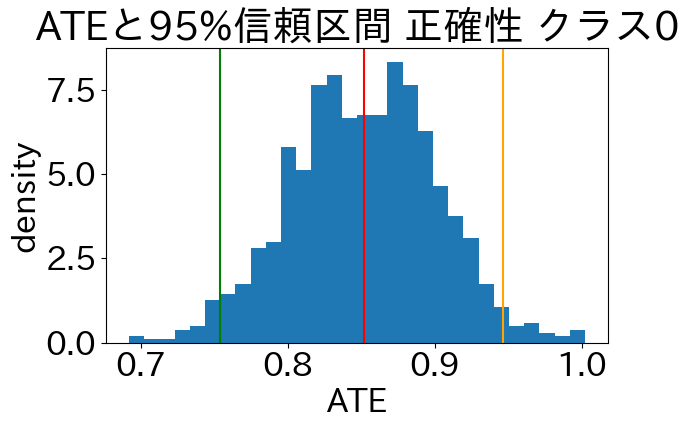

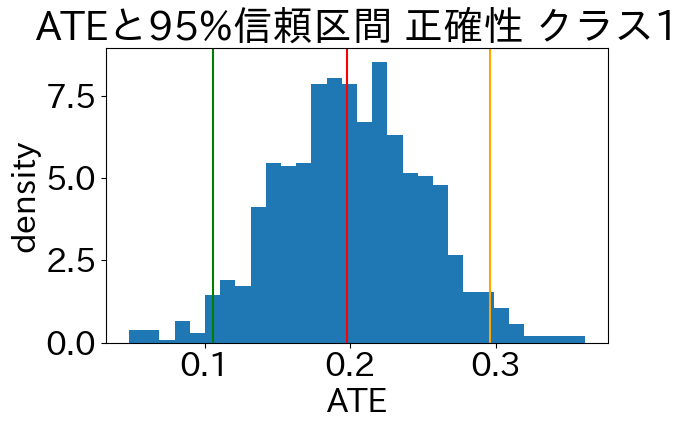

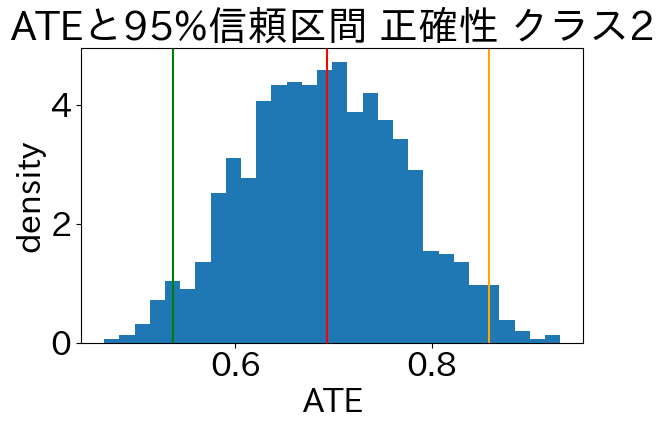

In [15]:
res_if_seg = plot_if_guard_seg(
    A0, Y0, score, nuis, seg0,
    cap=100, B=1000, seed=123, bins=30
)

In [16]:
idx0 = (seg0 == 2)
raw_diff = Y0[idx0 & (A0==1)].mean() - Y0[idx0 & (A0==0)].mean()
Y1 = Y0[idx0 & (A0==1)].mean()
Y0m = Y0[idx0 & (A0==0)].mean()
raw_diff, Y1, Y0m

(0.3201865423051298, 3.231578947368421, 2.911392405063291)

In [17]:
def oc_dr_cdf_by_seg(A, Y, nuis, seg, cap=None, level_labels=None):
    """
    クラス別 DR-CDF（F1-F0）を計算して DataFrame で返す。
    - A: (n,) treatment 0/1
    - Y: (n,) outcome を 0..K-1 にエンコードしたもの（あなたのYと同じ）
    - nuis: fit_cf_oc の戻り（e_hat, p_hat1, p_hat0 が必要）
    - seg: (n,) クラスID（0,1,2...）
    - cap: IF-guard（例: if_g=100）。Noneならトリムしない
    - level_labels: x軸ラベル（例：levels_sorted）。無ければ 0..K-1 を使う
    """
    A = np.asarray(A).astype(int).ravel()
    Y = np.asarray(Y).astype(int).ravel()
    seg = np.asarray(seg).astype(int).ravel()

    e  = np.clip(np.asarray(nuis["e_hat"]), 1e-4, 1-1e-4)
    p1 = np.asarray(nuis["p_hat1"])   # (n,K)
    p0 = np.asarray(nuis["p_hat0"])   # (n,K)
    
    K  = p1.shape[1]

    # 予測CDF（単調）
    F1 = np.cumsum(p1, axis=1)  # (n,K)
    F0 = np.cumsum(p0, axis=1)

    # IF-guard 重み
    if cap is None:
        w1 = A / e
        w0 = (1 - A) / (1 - e)
    else:
        w1 = np.minimum(1.0 / e, cap) * A
        w0 = np.minimum(1.0 / (1.0 - e), cap) * (1 - A)

    # x軸ラベル（元のカテゴリ値）を付けたい場合
    if level_labels is None:
        th = np.arange(K)
    else:
        th = np.asarray(level_labels)

    rows = []
    for g in np.unique(seg):
        idx_g = (seg == g)
        n_g = int(idx_g.sum())
        if n_g == 0:
            continue

        # overlapチェック（任意：危険なクラスはスキップしたい場合）
        n1 = int(((A == 1) & idx_g).sum())
        n0 = int(((A == 0) & idx_g).sum())
        # 必要なら下の条件でcontinue
        # if min(n1, n0) < 10:
        #     continue

        for c in range(K):
            Zc = (Y <= c).astype(float)      # 観測のI(Y<=c)
            mu1_c = F1[:, c]                 # 予測 F1(c|X)
            mu0_c = F0[:, c]                 # 予測 F0(c|X)

            # DR補正（個体別）
            psi1 = mu1_c + w1 * (Zc - mu1_c)
            psi0 = mu0_c + w0 * (Zc - mu0_c)
            F1g = psi1[idx_g].mean()
            F0g = psi0[idx_g].mean()
            F1g = float(np.clip(F1g, 0.0, 1.0))
            F0g = float(np.clip(F0g, 0.0, 1.0))
            score_c = psi1 - psi0

            # クラス内平均＆SE（EIFの分散/ n）
            tau = F1g - F0g
            phi = score_c[idx_g] - float(score_c[idx_g].mean())
            se  = float(np.sqrt(np.mean(phi**2) / n_g))
            
            if float(psi1[idx_g].mean()) <= 0.00000:
                float(psi1[idx_g].mean()) == 0.00000

            rows.append({
                "seg": int(g),
                "c": int(c),
                "threshold": th[c],
                "n": n_g,
                "n_treat1": n1,
                "n_treat0": n0,
                "F1_dr": float(F1g),
                "F0_dr": float(F0g),
                "tau_c": tau,
                "se_c": se,
                "ci_low": tau - 1.96*se,
                "ci_high": tau + 1.96*se,
            })
    return pd.DataFrame(rows)

In [18]:
seg = data["seg_opt"].to_numpy()    # クラス列（しきい値分割で作ったもの）
A   = data["treatment"].to_numpy()
# Y は 0..K-1 にエンコード済みのあなたの Y を使う
# levels_sorted も既にあるはず（元の1..5など）

# if_c = 25
cdf_seg = oc_dr_cdf_by_seg(
    A=A0, Y=Y0, nuis=nuis, seg=seg0,
    cap=None,                 
    level_labels=levels_sorted
)

print(cdf_seg.iloc[:, [0,1,6,7,10,11]])
# cdf_seg
# ["seg", "F1_dr", "F0_dr", "ci_low", "ci_high"]

    seg  c     F1_dr     F0_dr        ci_low       ci_high
0     0  0  0.004017  0.025542 -3.904745e-02 -4.002493e-03
1     0  1  0.016867  0.078915 -9.450863e-02 -2.958614e-02
2     0  2  0.171220  0.757940 -6.524733e-01 -5.209682e-01
3     0  3  0.820418  1.000000 -2.043673e-01 -1.547958e-01
4     0  4  1.000000  1.000000 -3.169860e-18  3.169860e-18
5     1  0  0.000803  0.000000 -1.020138e-03  2.626504e-03
6     1  1  0.003184  0.008501 -2.017920e-02  9.546192e-03
7     1  2  0.090269  0.218258 -2.074605e-01 -4.851737e-02
8     1  3  0.915037  0.981430 -1.177099e-01 -1.507552e-02
9     1  4  1.000000  1.000000 -6.408604e-18  6.408604e-18
10    2  0  0.000000  0.008519 -1.483597e-02 -2.201033e-03
11    2  1  0.000000  0.026563 -3.668787e-02 -1.643888e-02
12    2  2  0.000000  0.300880 -3.767234e-01 -2.250362e-01
13    2  3  0.608540  0.933381 -4.422247e-01 -2.074576e-01
14    2  4  1.000000  1.000000 -4.518510e-18  4.518510e-18


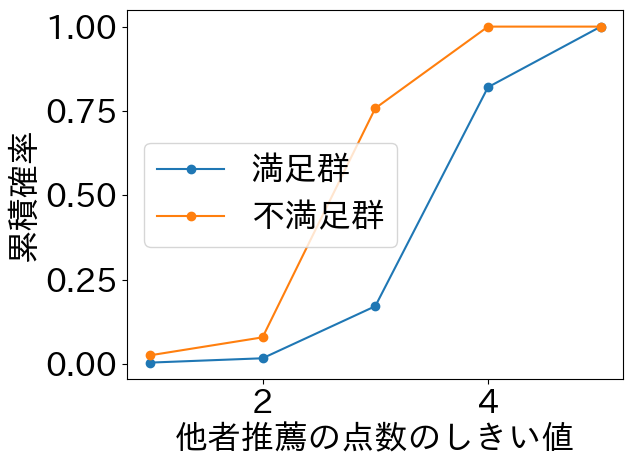

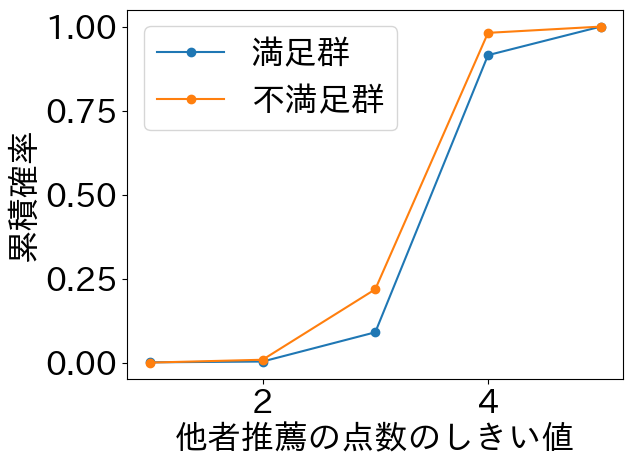

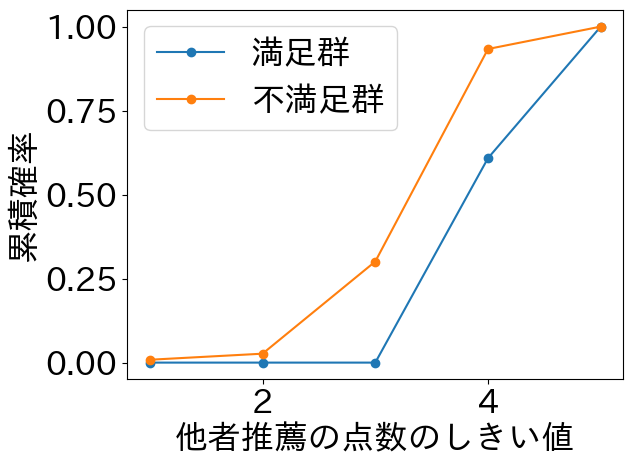

In [19]:
for g in sorted(cdf_seg["seg"].unique()):
    d = cdf_seg[cdf_seg["seg"] == g].sort_values("c")

    plt.figure()
    plt.plot(d["threshold"], d["F1_dr"], marker="o", label="満足群")
    plt.plot(d["threshold"], d["F0_dr"], marker="o", label="不満足群")
    plt.xlabel("他者推薦の点数のしきい値")
    plt.ylabel("累積確率")
    # plt.title(f"DR-CDF (seg={g})")
    plt.legend()
    plt.show()

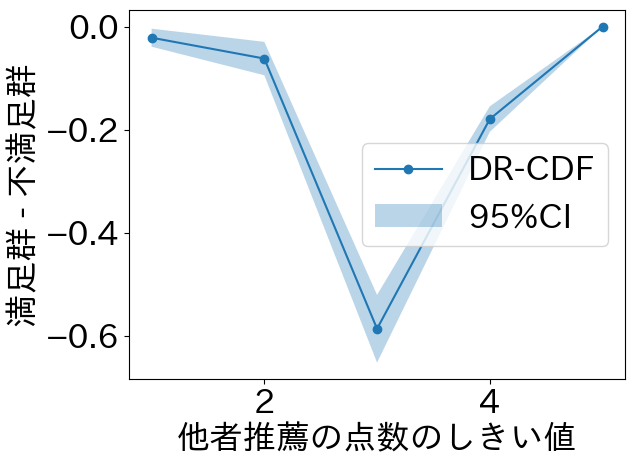

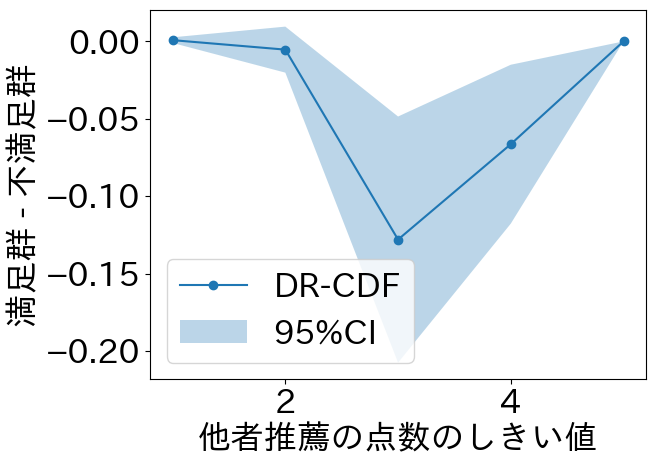

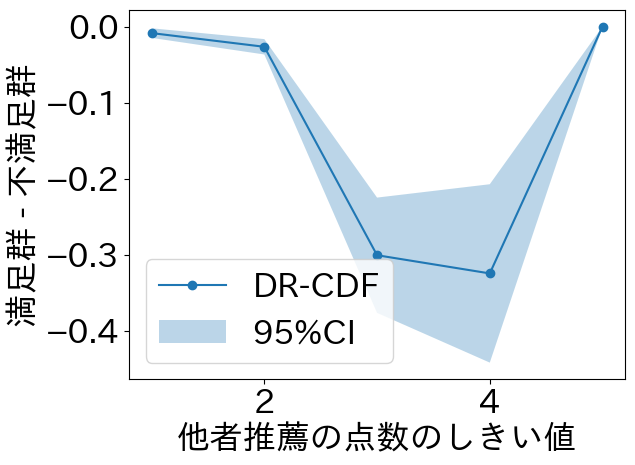

In [20]:
for g in sorted(cdf_seg["seg"].unique()):
    d = cdf_seg[cdf_seg["seg"] == g].sort_values("c")

    plt.figure()
    plt.plot(d["threshold"], d["tau_c"], marker="o", label="DR-CDF")
    plt.fill_between(d["threshold"], d["ci_low"], d["ci_high"], alpha=0.3, label="95%CI")
    plt.xlabel("他者推薦の点数のしきい値")
    plt.ylabel("満足群 - 不満足群")
    # plt.title(f"DR-CDF (seg={g})")
    plt.legend()
    plt.show()

In [21]:
# =========================================================
# pseudo_outcomes の定義（関数の外で再計算）
# =========================================================
# 観測されたアウトカムをスコア（0〜4）に変換
score_arr = np.asarray([0, 1, 2, 3, 4], dtype=float)
Z0 = score_arr[Y0]

# nuis(辞書)から予測値を取り出し、極端な傾向スコアをクリップ
e0 = np.clip(nuis["e_hat"], 1e-4, 1 - 1e-4)
mu1_0 = nuis["mu1_hat"]
mu0_0 = nuis["mu0_hat"]

# AIPWスコア（個人の擬似アウトカム）を1次元配列として計算
aipw_pseudo_outcomes = (mu1_0 - mu0_0) + (A0 / e0) * (Z0 - mu1_0) - ((1 - A0) / (1 - e0)) * (Z0 - mu0_0)

df_import = pd.read_csv("tau_hat_export.csv")
cluster_scores = df_import["tau_hat"].values

from sklearn.linear_model import Ridge

# 1. すでに計算済みの擬似アウトカムを目的変数として、Ridge回帰を学習
# ※ X1 は因果クラスタリング等に使った特徴量のデータフレーム（または配列）
linear_causal_model = Ridge(alpha=1.0, random_state=123)
linear_causal_model.fit(X1, aipw_pseudo_outcomes)

# 2. 線形モデルが予測した個人の因果効果スコア
linear_scores = linear_causal_model.predict(X1)

In [22]:
def calculate_heterogeneity_score(pseudo_outcomes, predicted_scores):
    """
    ユーザーを予測スコアで10等分（デシル）し、
    セグメント間ATEの【不偏分散】をHeterogeneity Scoreとして計算する関数
    """
    # 1. スコアが高い順（降順）に並べ替え
    order = np.argsort(predicted_scores)[::-1]
    sorted_outcomes = pseudo_outcomes[order]
    
    # 2. 10等分に分割
    deciles = np.array_split(sorted_outcomes, 10)
    
    # 3. 各デシル（グループ）の平均因果効果（ATE）を計算
    ates = [np.mean(d) for d in deciles]
    
    # 4. デシル間ATEの【不偏分散（Variance）】を計算
    # ddof=1 とすることで学術統計で一般的な「不偏分散」になります
    heterogeneity_score = np.var(ates, ddof=1)
    
    return heterogeneity_score

# =========================================================
# 各モデルのHeterogeneity Scoreを算出
# =========================================================
score_proposed = calculate_heterogeneity_score(aipw_pseudo_outcomes, -S0)
# score_cluster = calculate_heterogeneity_score(aipw_pseudo_outcomes, cluster_scores)
# score_linear = calculate_heterogeneity_score(aipw_pseudo_outcomes, linear_scores)

print(score_proposed)

# 論文の本文や表（Table）にそのまま載せられるようにDataFrame化
heterogeneity_results = pd.DataFrame({
    "Method": [
        "Proposed Method (-S0)", 
        # "Causal Clustering (RF)", 
        # "Linear Model (Ridge)"
    ],
    "Heterogeneity Score (ATE Variance)": [
        score_proposed, 
        # score_cluster, 
        # score_linear
    ]
})

print("==== Heterogeneity Score (Evaluation of Segmentation Quality) ====")
print(heterogeneity_results.to_string(index=False))

0.2745640930859779
==== Heterogeneity Score (Evaluation of Segmentation Quality) ====
               Method  Heterogeneity Score (ATE Variance)
Proposed Method (-S0)                            0.274564


In [23]:
# smd_num = 0
# seg_smd = [i["seg_mean_abs_SMD"] for i in per_seg_summary]
# for i in range(len(seg_smd)):
#     smd_num += seg_smd[i]
# smd_num /= 3
smd_num = (
    sum(row["n"] * row["seg_mean_abs_SMD"] for row in per_seg_summary)
    /sum(row["n"] for row in per_seg_summary)
)
score_proposed /= smd_num
print(score_proposed)

2.374609039743838


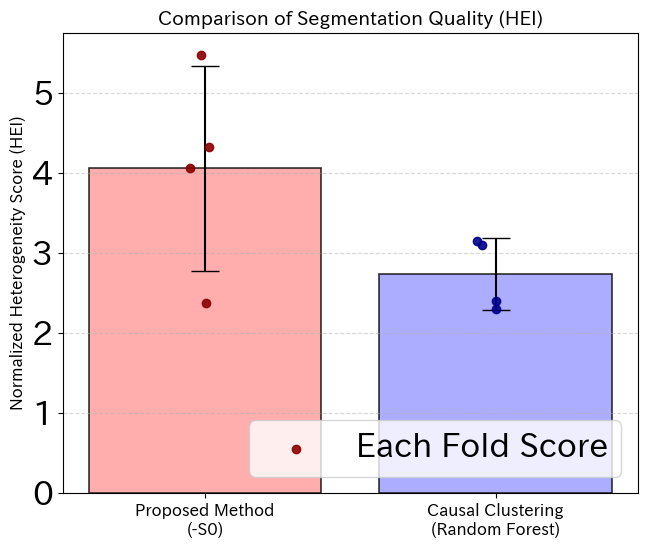

In [24]:
# いただいた4回分（Foldごと）のHEIスコア
hei_proposed = [2.374609039743838, 5.471208523395044, 4.0615359970285985, 4.325312698877328]
hei_rf = [3.1007619303123373, 3.1530651964461756, 2.296957473061643, 2.3988665311251305]

# 平均値と標準偏差（エラーバー用）の計算
means = [np.mean(hei_proposed), np.mean(hei_rf)]
stds = [np.std(hei_proposed, ddof=1), np.std(hei_rf, ddof=1)]

labels = ['Proposed Method\n(-S0)', 'Causal Clustering\n(Random Forest)']
x = np.arange(len(labels))

plt.figure(figsize=(7, 6))

# 1. 平均値の棒グラフを描画
bars = plt.bar(x, means, yerr=stds, capsize=10, 
               color=['#ff9999', '#9999ff'], alpha=0.8, edgecolor='black', linewidth=1.2)

# 2. 各Foldの実際のスコアを「ドット」として重ねて描画（これが論文で信頼される書き方です）
# ドットが重ならないようにX軸方向に少しだけ散らします（ジッター）
jitter_proposed = np.random.normal(0, 0.04, size=len(hei_proposed))
jitter_rf = np.random.normal(1, 0.04, size=len(hei_rf))

plt.scatter(jitter_proposed, hei_proposed, color='darkred', zorder=3, alpha=0.9, label='Each Fold Score')
plt.scatter(jitter_rf, hei_rf, color='darkblue', zorder=3, alpha=0.9)

# 3. 装飾
plt.ylabel('Normalized Heterogeneity Score (HEI)', fontsize=12)
plt.title('Comparison of Segmentation Quality (HEI)', fontsize=14)
plt.xticks(x, labels, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')

# グラフの余白を自動調整
plt.tight_layout()
plt.show()